# Лабораторна робота 6
## 2 Варіант

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

$$
y' = (1 - x^2)y + F(x)
$$
$$
y = \cos(x)
$$
$$
y' = -\sin(x)
$$
$$
-\sin(x) = (1 - x^2)\cos(x) + F(x)
$$
$$
F(x) = -\sin(x) - (1 - x^2)\cos(x)
$$

In [ ]:
def y_exact(x):
    return np.cos(x)

def F(x, y):
    return -np.sin(x) - (1 - x**2)*np.cos(x)

def f(x, y):
    return (1 - x**2)*y + F(x, y)

In [ ]:
h = 0.1
x0 = 0
y0 = y_exact(x0)

x = np.arange(0, 2 + h, h)  
n = len(x)

## Метод Рунге-Кутта

In [35]:
def runge_kutta(f, x0, y0, h, n):
    x = np.zeros(n)
    y = np.zeros(n)

    x[0] = x0
    y[0] = y0

    for i in range(n - 1):
        x[i+1] = x[i] + h

        k1 = h * f(x[i], y[i])
        k2 = h * f(x[i] + h/2, y[i] + k1/2)
        k3 = h * f(x[i] + h/2, y[i] + k2/2)
        k4 = h * f(x[i] + h, y[i] + k3)

        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4)/6

    return x, y

## Метод Адамса-Башфорта

In [36]:
def adams_bashforth(f, x, y_start, h):
    
    n = len(x)
    y = np.zeros(n)

    y[:4] = y_start[:4]

    for i in range(3, n-1):
        f0 = f(x[i], y[i])
        f1 = f(x[i-1], y[i-1])
        f2 = f(x[i-2], y[i-2])
        f3 = f(x[i-3], y[i-3])

        y[i+1] = y[i] + h*(55*f0 - 59*f1 + 37*f2 - 9*f3)/24

    return y

## Результат

In [37]:
x_rk, y_rk = runge_kutta(f, x0, y0, h, n)
y_ab = adams_bashforth(f, x_rk, y_rk[:4], h)

y_true = y_exact(x_rk)

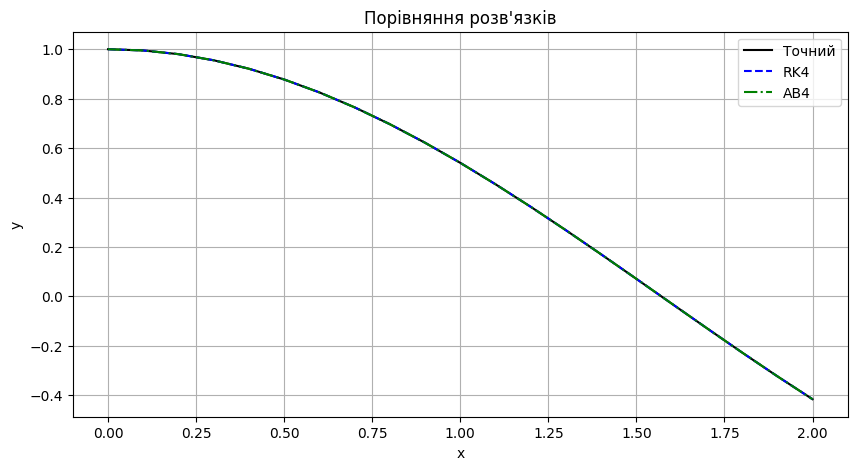

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(x_rk, y_true, 'k', label='Точний')
plt.plot(x_rk, y_rk, 'b--', label='RK4')
plt.plot(x_rk, y_ab, 'g-.', label='AB4')
plt.title("Порівняння розв'язків")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

## Похибка

In [39]:
e_rk = np.abs(y_true - y_rk)
e_ab = np.abs(y_true - y_ab)

print("Макс похибка RK4:", np.max(e_rk))
print("Макс похибка AB4:", np.max(e_ab))

Макс похибка RK4: 3.25331101530546e-06
Макс похибка AB4: 2.2668358628321478e-05


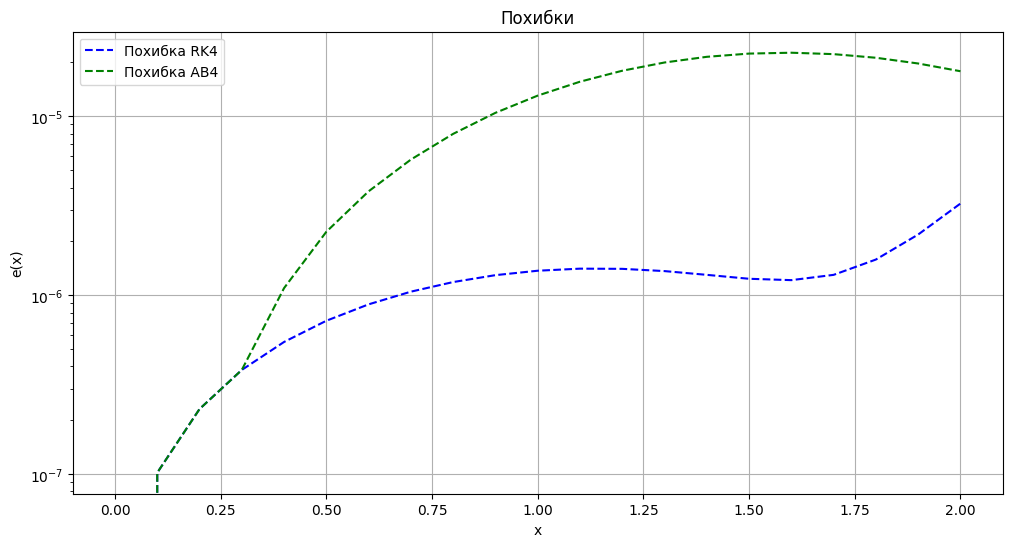

In [40]:
plt.figure(figsize=(12,6))
plt.plot(x_rk, e_rk, 'b--', label='Похибка RK4')
plt.plot(x_rk, e_ab, 'g--', label='Похибка AB4')

plt.title('Похибки')
plt.xlabel('x')
plt.ylabel('e(x)')
plt.legend()
plt.grid(True)
plt.yscale('log') 

In [43]:
table = pd.DataFrame({
    'x': np.round(x_rk, 3),
    'y_exact': np.round(y_true, 6),
    'y_RK4': np.round(y_rk, 6),
    'y_AB4': np.round(y_ab, 6),
    'e_RK4': np.round(e_rk, 6),
    'e_AB4': np.round(e_ab, 6)
})

print(table)

      x   y_exact     y_RK4     y_AB4     e_RK4     e_AB4
0   0.0  1.000000  1.000000  1.000000  0.000000  0.000000
1   0.1  0.995004  0.995004  0.995004  0.000000  0.000000
2   0.2  0.980067  0.980067  0.980067  0.000000  0.000000
3   0.3  0.955336  0.955337  0.955337  0.000000  0.000000
4   0.4  0.921061  0.921062  0.921062  0.000001  0.000001
5   0.5  0.877583  0.877583  0.877585  0.000001  0.000002
6   0.6  0.825336  0.825337  0.825339  0.000001  0.000004
7   0.7  0.764842  0.764843  0.764848  0.000001  0.000006
8   0.8  0.696707  0.696708  0.696715  0.000001  0.000008
9   0.9  0.621610  0.621611  0.621620  0.000001  0.000010
10  1.0  0.540302  0.540304  0.540315  0.000001  0.000013
11  1.1  0.453596  0.453598  0.453612  0.000001  0.000016
12  1.2  0.362358  0.362359  0.362376  0.000001  0.000018
13  1.3  0.267499  0.267500  0.267519  0.000001  0.000020
14  1.4  0.169967  0.169968  0.169989  0.000001  0.000022
15  1.5  0.070737  0.070738  0.070760  0.000001  0.000022
16  1.6 -0.029